<a href="https://colab.research.google.com/github/ariyanatef/Can-Thyroid-Cancer-be-Predicted-Using-Machine-Learning/blob/main/Thyroid_Cancer_Recurrence_Final_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [1]:
# Data manipulation and numerical operations
import pandas as pd   # For data manipulation and analysis
import numpy as np    # For numerical operations

# Data visualization libraries
import matplotlib.pyplot as plt   # For plotting and visualizations
import graphviz   # For visualizing decision trees

# Scikit-learn: Model selection and evaluation
from sklearn.model_selection import train_test_split   # For splitting the data into training and testing sets
from sklearn.metrics import accuracy_score, classification_report  # For evaluating model performance
from sklearn.metrics import roc_curve, roc_auc_score  # For calculating ROC curve and AUC

# Scikit-learn: Preprocessing
from sklearn.preprocessing import LabelEncoder   # For encoding categorical labels into numeric values
from sklearn.preprocessing import OneHotEncoder  # For encoding categorical features using one-hot encoding

# Scikit-learn: Machine learning model
from sklearn.ensemble import RandomForestClassifier  # For building random forest models

# Scikit-learn: Tree visualization
from sklearn.tree import export_graphviz  # For exporting decision trees in DOT format
from sklearn.tree import plot_tree  # For plotting decision trees

# 1. Process the Data with All Features

## 1.1 Loading the Data into a Pandas DataFrame

Code Block 1A

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Code Block 1B

In [3]:
# Specify the file path to the CSV file containing the thyroid cancer recurrence data
csv_path = "/content/drive/MyDrive/Thyroid Cancer Recurrence/thyroid_data.csv"

# Read the CSV file into a DataFrame using pandas
df = pd.read_csv(csv_path)

# Display the first few rows of the DataFrame to get a quick overview of the data
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,T1a,N0,M0,I,Excellent,No


### 1.1.1 Label Encoding

Code Block 1C

In [ ]:
# Label encoding yes or no values

# Define mapping
mapping = {'No': 0, 'Yes': 1}

# TODO: Insert names of columns that have Yes or No values
boolean_columns = ['Smoking', 'Hx Smoking', 'Hx Radiotherapy', 'Recurred']
df[boolean_columns] = df[boolean_columns].map(mapping.get)

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,0,0,0,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Indeterminate,0
1,34,F,0,1,0,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,0
2,30,F,0,0,0,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,0
3,62,F,0,0,0,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,0
4,62,F,0,0,0,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,T1a,N0,M0,I,Excellent,0


Code Block 1D

In [4]:
# Label encode features with only 2 values

# Initialize the LabelEncoder
le = LabelEncoder()

# TODO: Input column names that only have 2 values
columns_to_encode = ['Gender', 'Focality', 'M']

for column in columns_to_encode:
  df[column] = le.fit_transform(df[column])

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,0,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,1,T1a,N0,0,I,Indeterminate,No
1,34,0,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,1,T1a,N0,0,I,Excellent,No
2,30,0,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,1,T1a,N0,0,I,Excellent,No
3,62,0,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,1,T1a,N0,0,I,Excellent,No
4,62,0,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,0,T1a,N0,0,I,Excellent,No


### 1.1.2 Label Encoding with Order

Code Block 1E

In [13]:
df['Physical Examination'].unique()

array(['Single nodular goiter-left', 'Multinodular goiter',
       'Single nodular goiter-right', 'Normal', 'Diffuse goiter'],
      dtype=object)

Code Block 1F

In [6]:
# Get unique values in the 'Physical Examination' column
unique_values = df['Physical Examination'].unique()

# TODO: Define mapping for 'Physical Examination'
mapping = {'Normal': 0,
           'Diffuse Goiter' : 1,
           'Single nodular goiter-left' :2,
           'Single nodular goiter-right' : 2,
           'Multinodular goiter' : 3,
           np.nan: 0 # Add nan to mapping with value of 0
}

# Add any missing unique values to the mapping:
for value in unique_values:
  if value not in mapping:
    mapping[value] = len(mapping)

df['Physical Examination'] = df['Physical Examination'].map(mapping)

if np.isnan(df['Physical Examination'].unique()).any():
  raise ValueError('Your output has NaN values. Check your mapping inputs to make sure they exactly match the unique values.')

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,2,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,3,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,2,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,2,No,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,3,No,Micropapillary,Multi-Focal,T1a,N0,M0,I,Excellent,No


Code Block 1G

In [12]:
# TODO: Use the .unique() function to find the unique values for 'Adenopathy'
df['Adenopathy'].unique()

array(['No', 'Right', 'Extensive', 'Left', 'Bilateral', 'Posterior'],
      dtype=object)

Code Block 1H

In [9]:
# Get unique values in the 'Adenopathy' column
unique_values = df['Adenopathy'].unique()

# TODO: Define mapping for 'Adenopathy'
mapping = {'No':0,
           'Right/Left' : 1,
           'Posterior': 2,
           'Bilateral' : 3,
           'Extensive' : 4,
           np.nan: 0
}

# Add any missing unique values to the mapping:
for value in unique_values:
  if value not in mapping:
    mapping[value] = len(mapping)

df['Adenopathy'] = df['Adenopathy'].map(mapping)

if np.isnan(df['Adenopathy'].unique()).any():
  raise ValueError('Your output has NaN values. Check your mapping inputs to make sure they exactly match the unique values.')

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,0,Micropapillary,Uni-Focal,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,0,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,0,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,0,Micropapillary,Uni-Focal,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,0,Micropapillary,Multi-Focal,T1a,N0,M0,I,Excellent,No


Code Block 1I

In [14]:
# TODO: Use the .unique() function to find the unique values for 'Pathology'
df['Pathology'].unique()

array(['Micropapillary', 'Papillary', 'Follicular', 'Hurthle cell'],
      dtype=object)

Code Block 1J

In [15]:
# Get unique values in the 'Pathology' column
unique_values = df['Pathology'].unique()

# TODO: Define mapping for 'Pathology'
mapping = {'Micropapillary':0,
           'Papillary' :1,
           'Follicular' :2,
           'Hurthle Cell' :3,
           np.nan: 0
}

# Add any missing unique values to the mapping:
for value in unique_values:
  if value not in mapping:
    mapping[value] = len(mapping)

df['Pathology'] = df['Pathology'].map(mapping)

if np.isnan(df['Pathology'].unique()).any():
  raise ValueError('Your output has NaN values. Check your mapping inputs to make sure they exactly match the unique values.')

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,0,Uni-Focal,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,0,Uni-Focal,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,0,Multi-Focal,T1a,N0,M0,I,Excellent,No


Code Block 1K

In [17]:
# TODO: Use the .unique() function to find the unique values for 'T'
df['T'].unique()

array(['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b'], dtype=object)

Code Block 1L

In [18]:
# Get unique values in the 'T' column
unique_values = df['T'].unique()

# TODO: Define mapping for 'T'
mapping = {'T1a':0,
           'T1b' :1,
           'T2' :2,
           'T3a' :3,
           'T4a' :4,
           'T4b' :5,
           np.nan: 0
}

for value in unique_values:
  if value not in mapping:
    mapping[value] = len(mapping)

df['T'] = df['T'].map(mapping)

if np.isnan(df['T'].unique()).any():
  raise ValueError('Your output has NaN values. Check your mapping inputs to make sure they exactly match the unique values.')

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,0,Uni-Focal,0,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,0,Uni-Focal,0,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,0,Multi-Focal,0,N0,M0,I,Excellent,No


Code Block 1M

In [19]:
# TODO: Use the .unique() function to find the unique values for 'N'
df['N'].unique()

array(['N0', 'N1b', 'N1a'], dtype=object)

Code Block 1N

In [20]:
# TODO: Define mapping for 'N'
unique_values = df['N'].unique()
mapping = {'N0':0,
           'N1a':1,
           'N1b':2,
           np.nan: 0

}

for value in unique_values:
  if value not in mapping:
    mapping[value] = len(mapping)

df['N'] = df['N'].map(mapping)

if np.isnan(df['N'].unique()).any():
  raise ValueError('Your output has NaN values. Check your mapping inputs to make sure they exactly match the unique values.')

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,0,Uni-Focal,0,0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,0,Uni-Focal,0,0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,0,Multi-Focal,0,0,M0,I,Excellent,No


Code Block 1O

In [21]:
# TODO: Use the .unique() function to find the unique values for 'Stage'
df['Stage'].unique()

array(['I', 'II', 'IVB', 'III', 'IVA'], dtype=object)

Code Block 1P

In [22]:
# TODO: Define mapping for 'Stage'
unique_values = df['Stage'].unique()

mapping = {'I':0,
           'II':1,
           'III':2,
           'IVA' :3,
           np.nan: 0

}

for value in unique_values:
  if value not in mapping:
    mapping[value] = len(mapping)

df['Stage'] = df['Stage'].map(mapping)

if np.isnan(df['Stage'].unique()).any():
  raise ValueError('Your output has NaN values. Check your mapping inputs to make sure they exactly match the unique values.')

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,0,Uni-Focal,0,0,M0,0,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,0,Uni-Focal,0,0,M0,0,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,0,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,0,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,0,Multi-Focal,0,0,M0,0,Excellent,No


Code Block 1Q

In [23]:
# TODO: Use the .unique() function to find the unique values for 'Response'
df['Response'].unique()

array(['Indeterminate', 'Excellent', 'Structural Incomplete',
       'Biochemical Incomplete'], dtype=object)

Code Block 1R

In [24]:
# TODO: Define mapping for 'Response'
unique_values = df['Response'].unique()
mapping = {'Excellent':0,
           'Indeterminate':1,
           'Biochemical Incomplete':2,
           'Structural Incomplete':3,
           np.nan: 0
}

for value in unique_values:
  if value not in mapping:
    mapping[value] = len(mapping)

df['Response'] = df['Response'].map(mapping)

if np.isnan(df['Response'].unique()).any():
  raise ValueError('Your output has NaN values. Check your mapping inputs to make sure they exactly match the unique values.')

df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,0,Uni-Focal,0,0,M0,0,1,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,0,Uni-Focal,0,0,M0,0,0,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,0,0,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,0,0,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,0,Multi-Focal,0,0,M0,0,0,No


### 1.1.3 One-Hot Encoding

Code Block 1S

In [25]:
# Initialize a OneHotEncoder object
ohe = OneHotEncoder()

# Fit the OneHotEncoder to the 'Thyroid Function' column of the dataframe 'df'
# and transform it into a one-hot encoded array. The 'toarray()' method
# converts the sparse matrix output into a dense numpy array.
ohe.fit_transform(df[['Thyroid Function']]).toarray()

array([[0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

Code Block 1T

In [26]:
# Fit the OneHotEncoder to the 'Thyroid Function' column of the dataframe 'df'
# and transform it into a one-hot encoded array. The 'toarray()' method
# converts the sparse matrix output into a dense numpy array.
feature_array = ohe.fit_transform(df[['Thyroid Function']]).toarray()

# Get the category labels from the fitted OneHotEncoder
feature_labels = ohe.categories_

# Convert the list of arrays (from ohe.categories_) to a flattened numpy array
feature_labels = np.array(feature_labels).ravel()

# Create a DataFrame from the one-hot encoded array with column names set to the flattened feature labels
pd.DataFrame(feature_array, columns=feature_labels)

,Clinical Hyperthyroidism,Clinical Hypothyroidism,Euthyroid,Subclinical Hyperthyroidism,Subclinical Hypothyroidism
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
378,0.0,0.0,1.0,0.0,0.0
379,0.0,0.0,1.0,0.0,0.0
380,0.0,0.0,1.0,0.0,0.0
381,1.0,0.0,0.0,0.0,0.0


Code Block 1U

In [27]:
# Create a DataFrame from the one-hot encoded array (feature_array)
# using the flattened feature labels (feature_labels) as column names
features = pd.DataFrame(feature_array, columns=feature_labels)

# Concatenate the original dataframe (df) and the new one-hot encoded features (features)
# along the columns (axis=1). This results in a combined DataFrame with both the original
# and one-hot encoded features.
pd.concat([df, features], axis=1)

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,...,N,M,Stage,Response,Recurred,Clinical Hyperthyroidism,Clinical Hypothyroidism,Euthyroid,Subclinical Hyperthyroidism,Subclinical Hypothyroidism
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,0,Uni-Focal,...,0,M0,0,1,No,0.0,0.0,1.0,0.0,0.0
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,0,Uni-Focal,...,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,...,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,0,Uni-Focal,...,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,0,Multi-Focal,...,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,1,Uni-Focal,...,2,M1,5,2,Yes,0.0,0.0,1.0,0.0,0.0
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,1,Multi-Focal,...,2,M1,5,3,Yes,0.0,0.0,1.0,0.0,0.0
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,1,Multi-Focal,...,2,M1,5,3,Yes,0.0,0.0,1.0,0.0,0.0
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,5,Multi-Focal,...,2,M0,3,3,Yes,1.0,0.0,0.0,0.0,0.0


Code Block 1V

In [28]:
# Concatenate the original dataframe (df) with the new one-hot encoded features (features)
# along the columns (axis=1). This adds the one-hot encoded columns to the original dataframe.
df = pd.concat([df, features], axis=1)

# Drop the original 'Thyroid Function' column from the dataframe
# as it has been replaced by the one-hot encoded columns.
df = df.drop(['Thyroid Function'], axis='columns')

# Display the first few rows of the updated dataframe to inspect the result.
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiotherapy,Physical Examination,Adenopathy,Pathology,Focality,T,N,M,Stage,Response,Recurred,Clinical Hyperthyroidism,Clinical Hypothyroidism,Euthyroid,Subclinical Hyperthyroidism,Subclinical Hypothyroidism
0,27,F,No,No,No,Single nodular goiter-left,No,0,Uni-Focal,0,0,M0,0,1,No,0.0,0.0,1.0,0.0,0.0
1,34,F,No,Yes,No,Multinodular goiter,No,0,Uni-Focal,0,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0
2,30,F,No,No,No,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0
3,62,F,No,No,No,Single nodular goiter-right,No,0,Uni-Focal,0,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0
4,62,F,No,No,No,Multinodular goiter,No,0,Multi-Focal,0,0,M0,0,0,No,0.0,0.0,1.0,0.0,0.0


### 1.1.4 Split to Train and Test

Code Block 1W

In [29]:
# Drop the 'Recurred' column from the DataFrame to create the input features DataFrame
inputs = df.drop('Recurred', axis='columns')

# Select the target column 'Recurred' from the DataFrame to create the target DataFrame
target = df['Recurred']

Code Block 1X

In [30]:
# Split the data into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(inputs, target, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (306, 19)
X_test shape: (77, 19)
y_train shape: (306,)
y_test shape: (77,)


## 1.2 Train the Model

Code Block Y

In [31]:
# Creating a Decision Tree Classifier model object
model = RandomForestClassifier()

Code Block 1Z

In [33]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Loop over the categorial columns in the dataframe

for col in X_train.select_dtypes(include=['object']).columns:
  # Fit and transform the label encoder on the training data
  df[col] = label_encoder.fit_transform(df[col]).astype(str)
  X_train[col] = label_encoder.fit_transform(X_train[col])
  X_test[col] = label_encoder.transform(X_test[col])

# Fitting the model to the training data (X_train) and corresponding labels (y_train)
model.fit(X_train, y_train)

RandomForestClassifier()

## 1.3 Evaluate the Model

Code Block 1AA

In [34]:
# Evaluating the trained model's performance on the test data (X_test) and corresponding labels (y_test)
model.score(X_test, y_test)

0.987012987012987

y_test = Actual Group

y_pred = Predicted Group

Code Block 1BB

In [35]:
# Printing out the original group to compare
y_test = y_test.to_numpy()

print(y_test)

['No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No']


Code Block 1CC

In [36]:
# Using the trained model to make predictions on the test data (X_test)
y_pred = model.predict(X_test)

# Printing the predicted labels
print(y_pred)

['No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'Yes' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No']


## 1.4 Visualize the Model

Code Block 1DD

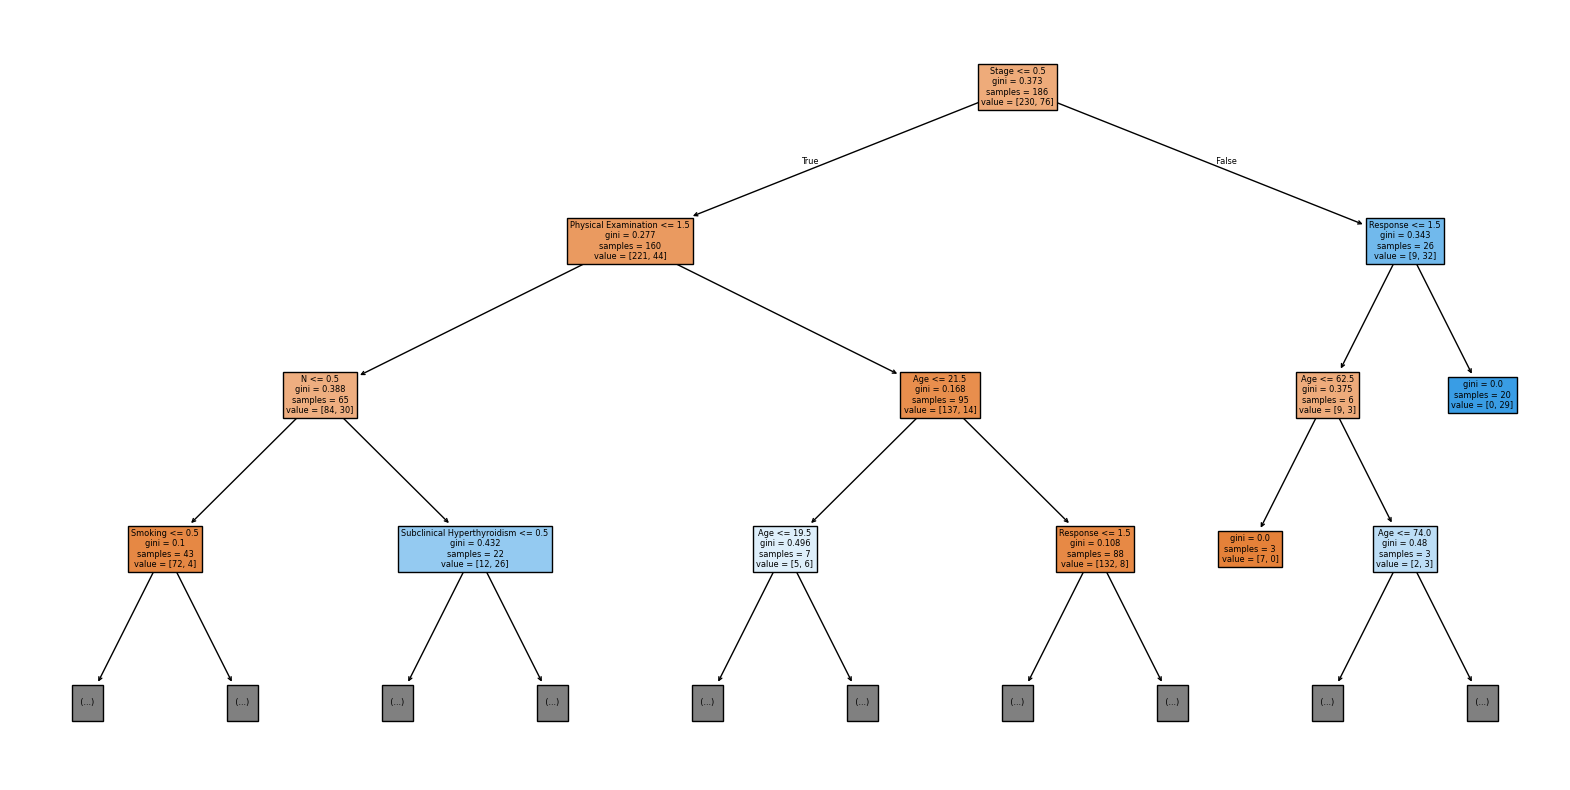

In [37]:
# TODO: Change this value to view the other decision trees
tree_number = 0

# TODO: Change this value to change the depth of the decision tree
max_depth = 3

feature_names = list(df.columns)
#feature_names.pop(99)

# Plot the first tree
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[tree_number], feature_names=feature_names, max_depth=max_depth, filled=True)
plt.show()

Code Block 1EE

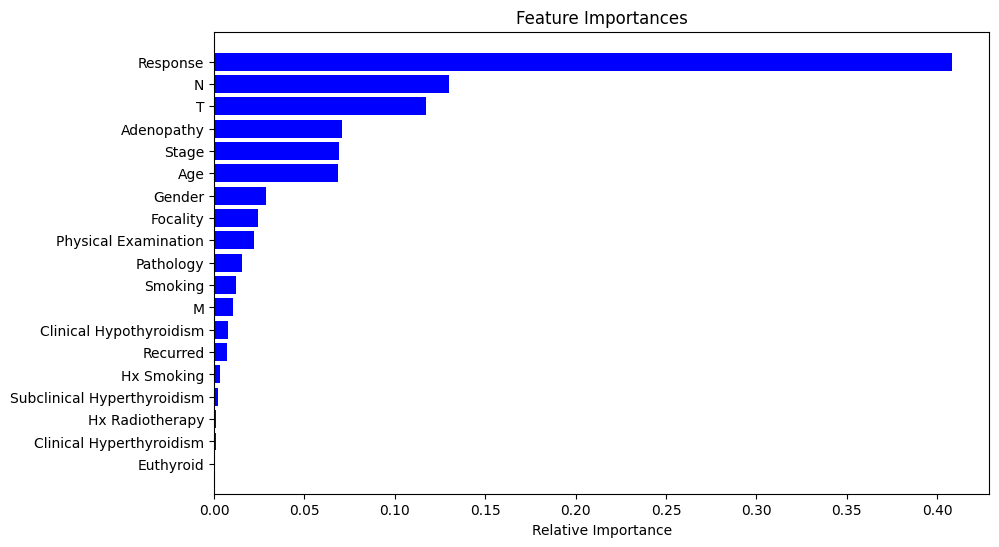

In [38]:
# Feature importance
importances = model.feature_importances_
indices = np.argsort(importances)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Code Block 1FF (Optional Advanced Analysis)

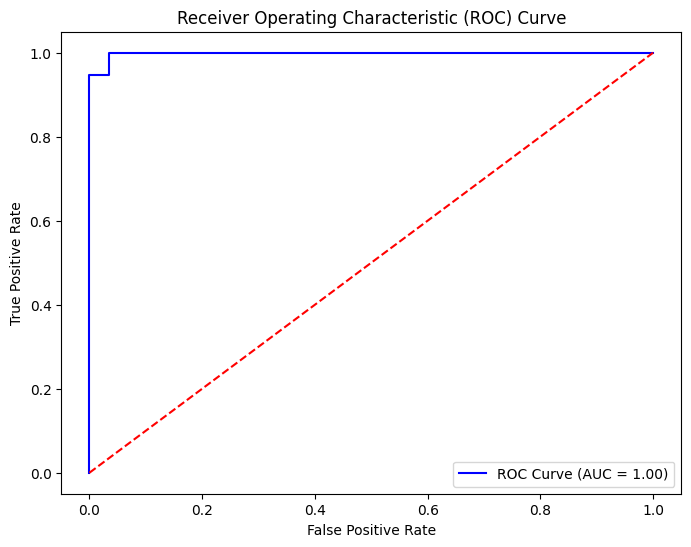

In [39]:
# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Convert y_test to numeric if it's not already
# Assuming 'No' maps to 0 and 'Yes' maps to 1
y_test_numeric = [1 if label =='Yes' else 0 for label in y_test]

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_prob)
auc_score = roc_auc_score(y_test_numeric, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()